In [1]:
import matplotlib.pyplot as plt
import numpy as np

from few.trajectory import EvolveTrajectory
from few.trajectory.events.resonance import ResonanceBase

# Prepare data

In [2]:
import h5py

jump_data = h5py.File("../tidal_resonance_data.h5", "r")

In [3]:
list(jump_data)

['m-1_k-1_n3',
 'm-1_k-1_n4',
 'm-1_k-3_n3',
 'm-1_k-3_n4',
 'm-1_k1_n1',
 'm-2_k-4_n3',
 'm-2_k-4_n4',
 'm-2_k0_n3',
 'm-2_k0_n4',
 'm-2_k2_n1',
 'm0_k-2_n3',
 'm0_k-2_n4',
 'm1_k-1_n3',
 'm1_k-1_n4',
 'm1_k-3_n3',
 'm1_k-3_n4',
 'm1_k1_n1',
 'm2_k-4_n3',
 'm2_k-4_n4',
 'm2_k0_n3',
 'm2_k0_n4',
 'm2_k2_n1']

In [4]:
k_res = 0
n_res = 3
m_res = -2
specific_jump_data = jump_data[f"m{m_res}_k{k_res}_n{n_res}/grid"]

avals = specific_jump_data["a"][:]
evals = specific_jump_data["e"][:]
ivals = np.acos(specific_jump_data["x"][:])

deltaE = specific_jump_data["dE"][:]
deltaL = specific_jump_data["dL"][:]
deltaQ = specific_jump_data["dQ"][:]

In [ ]:
from multispline.spline import TricubicSpline
from few.utils.mappings.pn import Y_to_x, x_to_Y
from few.trajectory.geodesic import get_kerr_geo_constants_of_motion, ELQ_to_pex

E_jump_re = TricubicSpline(avals, evals, ivals, deltaE.real)
L_jump_re = TricubicSpline(avals, evals, ivals, deltaL.real)
Q_jump_re = TricubicSpline(avals, evals, ivals, deltaQ.real)

E_jump_im = TricubicSpline(avals, evals, ivals, deltaE.imag)
L_jump_im = TricubicSpline(avals, evals, ivals, deltaL.imag)
Q_jump_im = TricubicSpline(avals, evals, ivals, deltaQ.imag)

def jump_func(a, p, e, Y, phi, omega_dot, nu, tidal_epsilon):
    m = -2
    k = 0
    n = 3

    x = Y_to_x(a, p, e, Y)
    iota = np.arccos(x)

    E, Lz, Q = get_kerr_geo_constants_of_motion(a, p, e, x)

    chi = m * phi[0] + k * phi[1] + n * phi[2]
    Gamma = m * omega_dot[0] + k * omega_dot[1] + n * omega_dot[2]
    
    Tres = np.sqrt(2 / np.abs(Gamma))

    # Just apply s = 1 ? 
    fact = tidal_epsilon * Tres * np.exp(1j * (np.sign(Gamma) * np.pi / 4 + chi)) * nu

    dE_jump = fact * (E_jump_re(a, e, iota) + 1j * E_jump_im(a, e, iota))
    dL_jump = fact * (L_jump_re(a, e, iota) + 1j * L_jump_im(a, e, iota))
    dQ_jump = fact * (Q_jump_re(a, e, iota) + 1j * Q_jump_im(a, e, iota))

    E_new = E + dE_jump.real
    Lz_new = Lz + dL_jump.real
    Q_new = Q + dQ_jump.real

    p, e, x = ELQ_to_pex(a, E_new, Lz_new, Q_new)

    Y = x_to_Y(a, p, e, x)

    return p, e, Y

# Define resonances event class

In [6]:
from few.trajectory.dopr853 import evaluate_single_dense_output_given_coefficients


class TidalResonanceTest(ResonanceBase):
    def __init__(self, *args, **kwargs):
        resonances = np.array(
            [
                [-2, 0, 3],
            ]
        )
        super().__init__(*args, resonance_indices=resonances, **kwargs)

    def action(
        self,
        t: float,
        y: np.ndarray,
        spline_info: tuple | None,
        integrator: object,
        idx: int = 0,
    ):
        a = integrator.model.parameters["a"]
        nu = integrator.model.parameters["nu"]
        epsilon = integrator.model.parameters["tidal_eps"]
        p = y[0]
        e = y[1]
        Y = y[2]
        phi = y[3:6]

        (s, dT, y_prev, coeffs) = spline_info

        omega_dot = evaluate_single_dense_output_given_coefficients(
            s, y_prev, coeffs, order=2, dt=dT
        )[3:6]

        p_new, e_new, Y_new = jump_func(a, p, e, Y, phi, omega_dot, nu, epsilon)
        print(p - p_new, e - e_new, Y - Y_new)
        y_new = y.copy()
        y_new[0] = p_new
        y_new[1] = e_new
        y_new[2] = Y_new

        return y_new

# Evolve trajectories

In [7]:
traj_gen_res = EvolveTrajectory(
    model="PN5",
    events=[
        TidalResonanceTest(),
    ],
)
traj_gen_no_res = EvolveTrajectory(model="PN5")

In [40]:
input_parameters = dict(m1=1e6, m2=1e1, a=0.7, p=11.0, e=0.3, Y=0.9, Phi_phi=0.5, tidal_eps=1e-9)

In [41]:
res_result = traj_gen_res(input_parameters, duration=np.inf)
no_res_result = traj_gen_no_res(input_parameters, duration=np.inf)

Resonance timescale: 36835.086849098014
2.240228447192294e-09 -7.685877767560356e-10 -7.15202341794452e-11
Resonance timescale: 36835.09199436339
2.240242658047009e-09 -7.685876379781575e-10 -7.152012315714273e-11


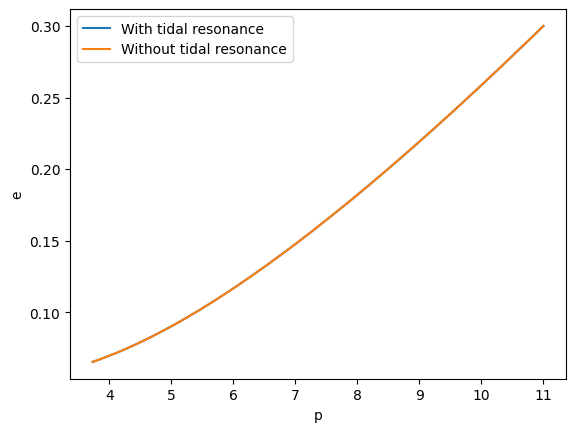

In [ ]:
plt.plot(res_result.p, res_result.e, label = "With tidal resonance")
plt.plot(no_res_result.p, no_res_result.e, label = "Without tidal resonance")
plt.xlabel("p")
plt.ylabel("e")
plt.legend()

Text(0, 0.5, 'Phi_phi difference')

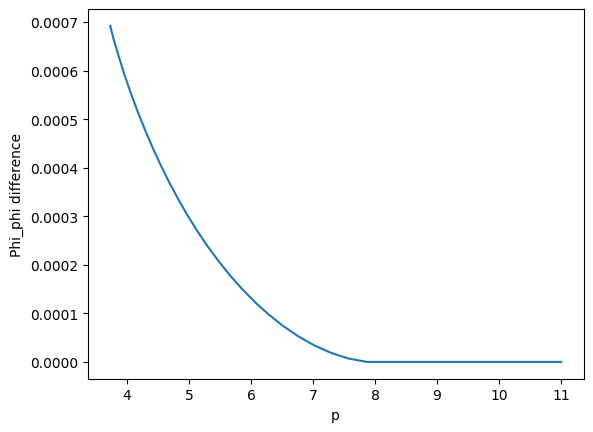

In [ ]:
plt.plot(res_result.p, res_result.Phi_phi - no_res_result(res_result.t).Phi_phi)
plt.xlabel("p")
plt.ylabel("Phi_phi difference")